# Tabel of contents

* **Introduction**
* **Objective**
* **Perceptron Foundations**
* **Data dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training**
    * Model Architecture, Model Building (PyTorch), and Model Training
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

The Perceptron, fundamentally a single artificial neuron, provides the basic building block for neural networks. When configured for regression, it operates as a sophisticated linear regression model trained via gradient descent. This project utilizes the PyTorch framework to construct and optimize this foundational model on the insurance charges dataset, which involves predicting a continuous financial outcome. This implementation is designed to provide a comprehensive, low-level view of how core deep learning concepts—such as custom module definition, automatic differentiation, and model training loops—are applied to a straightforward linear problem.

# Objective

The primary aims of this project are:

- To realize a linear regression solver by implementing a custom PyTorch `nn.Module` representing the Perceptron.
- To master the standard machine learning workflow, including critical steps like feature scaling and dimensionality reduction using Principal Component Analysis (PCA).
- To clearly demonstrate the training process using a validated loss function (MSE) and an industry-standard optimizer (Adam).
- To use advanced visualization techniques (2D contour plots and 3D surface plots) to visually articulate the exact output shape of a linear model and highlight its structural limitations when faced with complex, non-linear data distributions.

# Perceptron Foundations

The Perceptron is the simplest and foundational structure of an artificial neural network. When adapted for regression, it is fundamentally equivalent to performing a linear regression operation.

**The Architecture of a Regression Perceptron**

A Perceptron is a single neuron that takes multiple inputs and produces a single output.

- Input Layer and Features ($\mathbf{x}$): The Perceptron receives $N$ input features, represented as a vector $\mathbf{x} = [x_1, x_2, \dots, x_N]$. These inputs are the independent variables used to make a prediction.
- Weights ($\mathbf{w}$) and Bias ($b$): Each input $x_i$ is associated with a corresponding weight $w_i$. The weights represent the strength or importance of each feature in determining the output. A single bias term ($b$) is also included, which allows the model to shift the activation function result, providing an extra degree of freedom to fit the data.
- Net Input Function (Weighted Sum): The first step in the neuron's operation is the calculation of the net input ($z$), which is the weighted sum of the inputs plus the bias:
$$z = (\mathbf{x} \cdot \mathbf{w}) + b = \sum_{i=1}^{N} (x_i w_i) + b$$
This is a linear transformation of the input data.

- Activation Function (Identity): For a regression task, the goal is to predict a continuous value. Therefore, the output of the net input ($z$) is passed through an Identity Activation Function.
$$\text{Output } (\hat{y}) = f(z) = z$$
The identity function simply outputs its input, meaning the final prediction ($\hat{y}$) is directly the result of the linear transformation. This absence of a non-linear activation is what limits the single Perceptron to solving only linearly separable problems.

**Learning Process and Key Components**

The process of training the Perceptron involves finding the optimal weights and bias that minimize the difference between the predicted value ($\hat{y}$) and the true target value ($y$).

- Loss Function (Cost Function): To measure the prediction error, a Loss Function is used. For regression, the standard choices are:
    - Mean Squared Error (MSE): This is the most common choice, defined as $\text{MSE} = \frac{1}{m} \sum_{j=1}^{m} (\hat{y}_j - y_j)^2$. It penalizes large errors more severely than small ones due to the squaring operation.
    - Mean Absolute Error (MAE): Defined as $\text{MAE} = \frac{1}{m} \sum_{j=1}^{m} |\hat{y}_j - y_j|$. This provides a linear measure of error and is more robust to outliers.
- Optimization (Gradient Descent): The goal is to minimize the chosen loss function. This is achieved using an Optimizer, typically a variant of Gradient Descent (e.g., Stochastic Gradient Descent, Adam, RMSprop).
    - Gradient descent calculates the gradient (the partial derivatives of the loss function with respect to each weight and the bias). The gradient indicates the direction of steepest increase in the loss.
    - The weights and bias are then updated iteratively by moving in the opposite direction of the gradient, scaled by the learning rate ($\alpha$):


$$\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} - \alpha \frac{\partial \text{Loss}}{\partial \mathbf{w}}$$

$$b_{\text{new}} = b_{\text{old}} - \alpha \frac{\partial \text{Loss}}{\partial b}$$

- Prediction Surface (Hypersurface): Since the Perceptron performs a linear transformation, its prediction function defines a hyperplane in the feature space.
    - For two input features ($x_1, x_2$), the prediction surface is a 2D plane in a 3D space.
    - For $N$ input features, it is an $N$-dimensional hyperplane.
    - The model learns the parameters ($\mathbf{w}, b$) that position this hyperplane to best fit the training data points.

**Limitations of a Single Perceptron**

While simple and effective for linear problems, the single Perceptron has a fundamental limitation for regression: it can only model linear relationships.

- If the true underlying relationship between the features ($\mathbf{x}$) and the target ($y$) is non-linear (e.g., quadratic, exponential, or clustered non-linearly), a single Perceptron will fail to capture the complexity.
- To solve non-linear regression problems, it is necessary to introduce hidden layers with non-linear activation functions (like $\text{ReLU}$, $\text{Sigmoid}$, or $\text{Tanh}$) between the input and output layers, forming a Multi-Layer Perceptron (MLP).

# Data dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Variable Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">age</td>
    <td class="tg-7zrl">Edad del asegurado</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">sex</td>
    <td class="tg-7zrl">Género</td>
    <td class="tg-7zrl">Categorical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">bmi</td>
    <td class="tg-7zrl">Indice de masa corporal</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">children</td>
    <td class="tg-7zrl">Número de hijos</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">smoker</td>
    <td class="tg-7zrl">Indicador si fuma</td>
    <td class="tg-7zrl">Boolean</td>
  </tr>
  <tr>
    <td class="tg-7zrl">region</td>
    <td class="tg-7zrl">Región donde vive el asegurado</td>
    <td class="tg-7zrl">Categorical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">charges</td>
    <td class="tg-7zrl">Prima del seguro</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/mirichoi0218/insurance)**

# Pipeline Overview

The project follows a rigorous, multi-stage pipeline designed for efficiency and clarity:
- Data Preparation: Initial data cleaning, feature engineering, and the critical step of splitting data into separate training and test sets.
- Preprocessing: Standardization of numerical features and one-hot encoding of categorical inputs.
- Dimensionality Reduction: Application of PCA to reduce the feature count to two components for intuitive 2D and 3D plotting.
- Model Construction: Definition of the custom Perceptron class using PyTorch's module structure.
- Training: Iterative optimization using minibatches, Mean Squared Error loss, and an Early Stopping mechanism to prevent overfitting.
- Evaluation: Quantitative metric calculation on the unseen test set, complemented by qualitative visualization of the learned prediction surface.

# Approach

**Preprocessing Pipeline Approach**

The preprocessing stage ensures the data is in an optimal state for gradient-based learning, preventing scale disparity from biasing the weights.
- Feature Handling: Initial analysis guided the dropping of weakly correlated features, such as gender and region, to simplify the model space. The smoker variable, exhibiting strong correlation, was retained and converted via one-hot encoding.
- Scaling and Standardization: All numerical input features (age, bmi, children) underwent Standardization using the StandardScaler fitted exclusively on the training data. The target variable (charges) was scaled separately to facilitate its precise inverse-transformation post-prediction, ensuring meaningful error reporting.
- PCA Application: After standard scaling, PCA was fitted on the training features to extract the two most significant principal components. The transformation of both training and test features to this 2D subspace allows for the visualization of the model's behavior while retaining the core variance of the dataset.

**Model Training Approach**

The training methodology focuses on robust and efficient optimization of the single linear layer:
- Model Implementation: The Perceptron is implemented as a class inheriting from `nn.Module`, featuring a single `nn.Linear` layer. This layer lacks a non-linear activation function, confirming its role as a linear regressor.
- Loss and Optimizer: Training utilizes the Mean Squared Error (MSE) loss function, which quantifies the average squared deviation, and the Adam optimizer with a fixed learning rate of $0.01$, known for its efficiency in handling sparse gradients and convergence speed.
- Regularization: An Early Stopping mechanism is implemented. This callback monitors the model's performance on the validation set, terminating training if the validation loss fails to decrease for a predetermined number of epochs (`patience`). This critical step prevents the model from specializing too closely to the training data, promoting better generalization.

**Model Evaluation Approach**

Model assessment is performed through a two-pronged approach: metric computation on unseen data and predictive visualization.
- Quantitative Metrics: The model generates predictions on the independent test set. These predictions are then inverse-transformed to the original charge currency unit. The performance is assessed using standard regression metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the R-squared ($R^2$) Score. These values collectively measure the magnitude and quality of the fit.
- Qualitative Visualization: The most insightful part of the evaluation involves plotting the learned function. The model’s predictions are used to generate a continuous hyperplane within the 2D PCA feature space. This is visualized as:
    - A 2D contour plot, showing predicted charge values across the PCA plane.
    - A 3D surface plot, where the height of the plane represents the predicted charge.

# Setup Environments

**IMport Libraries**

In [ ]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
import missingno as msno
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error, r2_score

# Data Loading

The dataset, containing information on individual medical insurance charges and related features, is loaded into a Pandas DataFrame. The data includes both numerical features (age, bmi, children, charges) and categorical features (sex, smoker, region).

In [ ]:
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Train and Test Split**

Before any analysis or preprocessing begins, the complete dataset is partitioned into distinct training (80%) and testing (20%) subsets. This is a fundamental step to prevent data leakage, ensuring the final model evaluation is performed on data entirely unseen during training, thereby providing an unbiased assessment of the model's generalization capability.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (1070, 7)
test shape: (268, 7)


# Exploratory Data Analysis (EDA)

**Basic Statistics**

In [4]:
train.head()

,age,sex,bmi,children,smoker,region,charges
560,46,female,19.95,2,no,northwest,9193.83850
1285,47,female,24.32,0,no,northeast,8534.67180
1142,52,female,24.86,0,no,southeast,27117.99378
969,39,female,34.32,5,no,southeast,8596.82780
486,54,female,21.47,3,no,northwest,12475.35130


In [5]:
train.describe()

,age,bmi,children,charges
count,1070.000000,1070.000000,1070.000000,1070.000000
mean,39.357009,30.560397,1.107477,13346.089736
std,14.073960,6.043386,1.215983,12019.510778
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.205000,0.000000,4897.667387
50%,39.500000,30.210000,1.000000,9575.442100
75%,51.000000,34.496250,2.000000,16746.657400
max,64.000000,53.130000,5.000000,62592.873090


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1070 non-null   int64  
 1   sex       1070 non-null   object 
 2   bmi       1070 non-null   float64
 3   children  1070 non-null   int64  
 4   smoker    1070 non-null   object 
 5   region    1070 non-null   object 
 6   charges   1070 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 66.9+ KB


**Missing Values Detection**

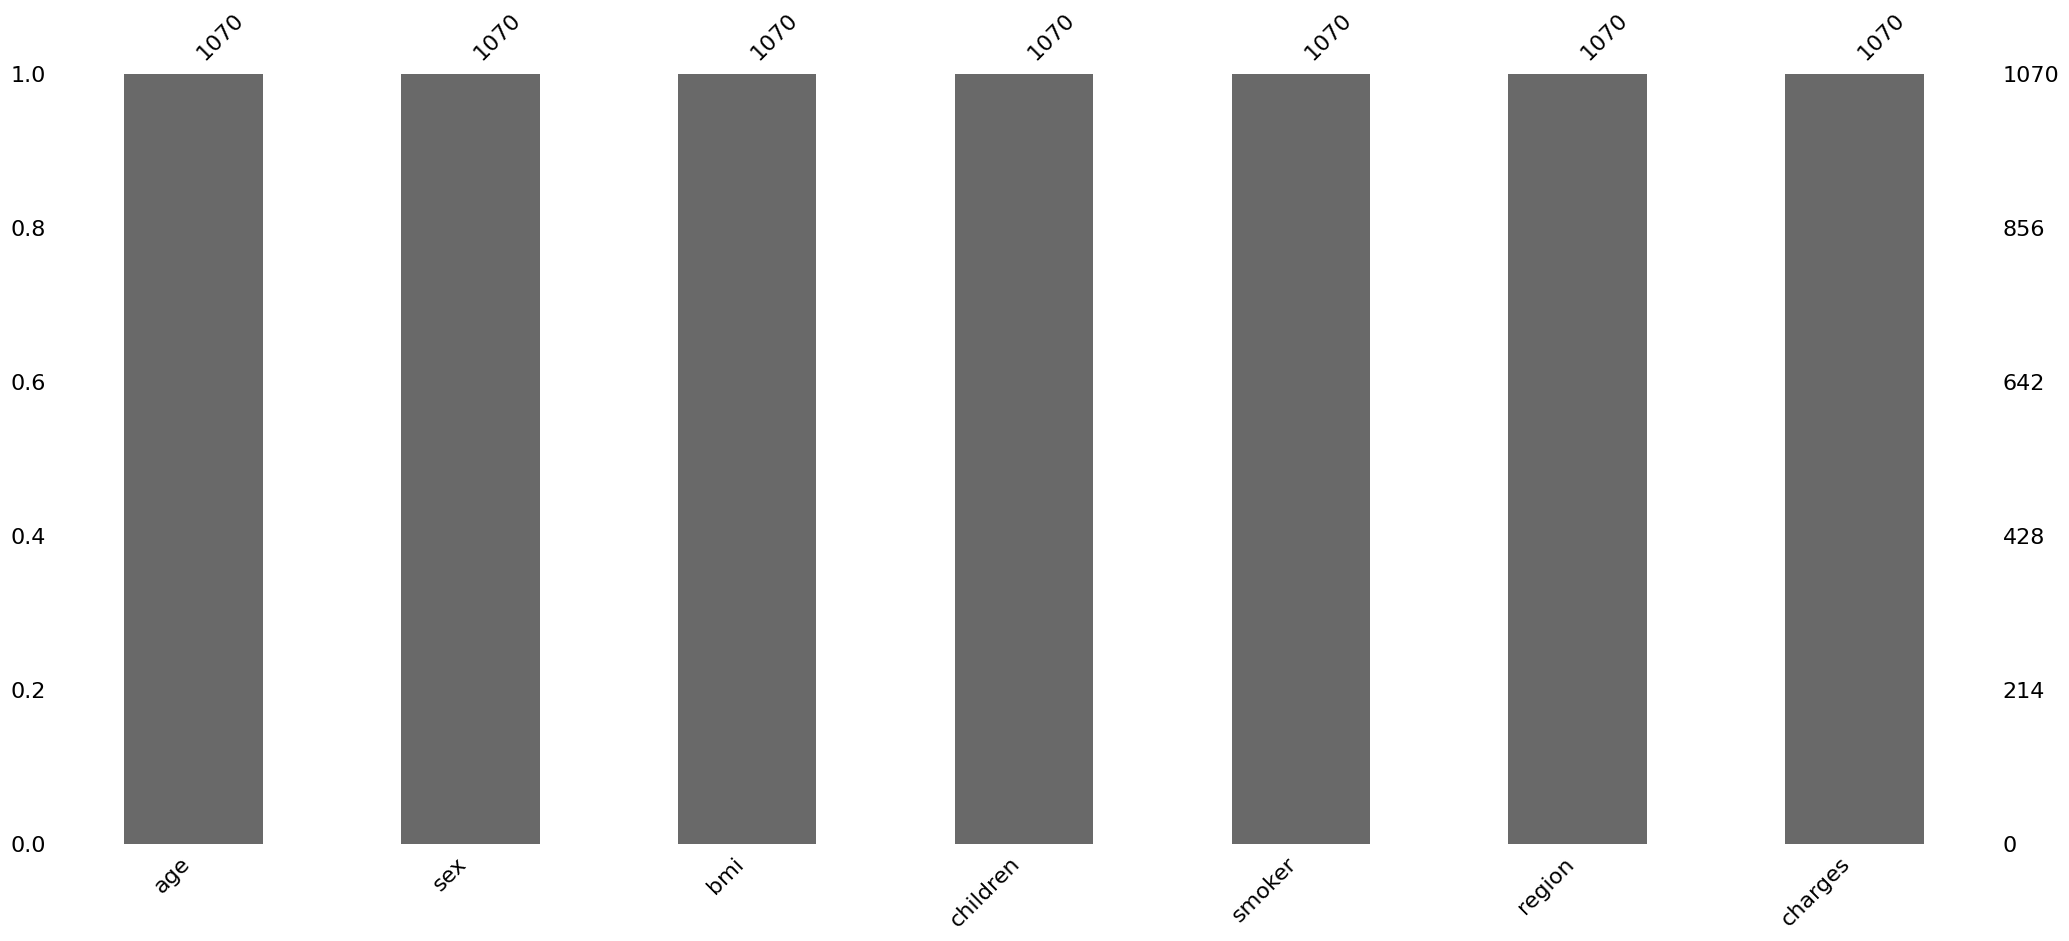

In [7]:
msno.bar(train)
plt.show()

In [8]:
train.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
test.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1070 non-null   int64  
 1   sex       1070 non-null   object 
 2   bmi       1070 non-null   float64
 3   children  1070 non-null   int64  
 4   smoker    1070 non-null   object 
 5   region    1070 non-null   object 
 6   charges   1070 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 66.9+ KB


**Initial Inspection**

The structural check confirms the dataset contains 7 columns with various data types (integers, floats, and objects). The non-null count across all columns equals the total number of entries in the training set, confirming the absence of missing values.

**Correlation Analysis**

Feature Encoding for Correlation: To analyze the relationship between categorical variables and the target (charges), categorical features are temporarily converted into a numerical format. Binary features (sex, smoker) are mapped to 0 and 1. The multi-class nominal feature (region) is converted using One-Hot Encoding to avoid imposing a false ordinal relationship.

Spearman Correlation Theory: The Spearman Rank Correlation coefficient is calculated. Unlike the Pearson coefficient, which measures linear relationships, Spearman's measures the strength and direction of a monotonic relationship (whether the variables tend to increase together). This is particularly useful as it is non-parametric, making it robust to non-normal data distributions and outliers, which are common in real-world features like medical charges.

In [ ]:
df_processed = train.copy()

df_processed['sex'] = df_processed['sex'].map({'female': 0, 'male': 1})
df_processed['smoker'] = df_processed['smoker'].map({'no': 0, 'yes': 1})

df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)
spearman_correlation_matrix = df_processed.corr(method='spearman')

print("Spearman Correlation Matrix:")
spearman_correlation_matrix

Spearman Correlation Matrix:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
age,1.000000,-0.007514,0.115408,0.074915,-0.052136,0.509846,0.016374,-0.019407,0.025868
sex,-0.007514,1.000000,0.013138,0.015945,0.070908,0.010859,0.017047,-0.008217,-0.013911
bmi,0.115408,0.013138,1.000000,0.001815,-0.000910,0.126142,-0.103393,0.227545,0.016553
children,0.074915,0.015945,0.001815,1.000000,0.023610,0.133833,0.044798,-0.023379,-0.009604
smoker,-0.052136,0.070908,-0.000910,0.023610,1.000000,0.661788,-0.030547,0.051450,-0.033688
charges,0.509846,0.010859,0.126142,0.133833,0.661788,1.000000,-0.009979,0.013010,-0.041507
region_northwest,0.016374,0.017047,-0.103393,0.044798,-0.030547,-0.009979,1.000000,-0.336290,-0.320954
region_southeast,-0.019407,-0.008217,0.227545,-0.023379,0.051450,0.013010,-0.336290,1.000000,-0.343194
region_southwest,0.025868,-0.013911,0.016553,-0.009604,-0.033688,-0.041507,-0.320954,-0.343194,1.000000


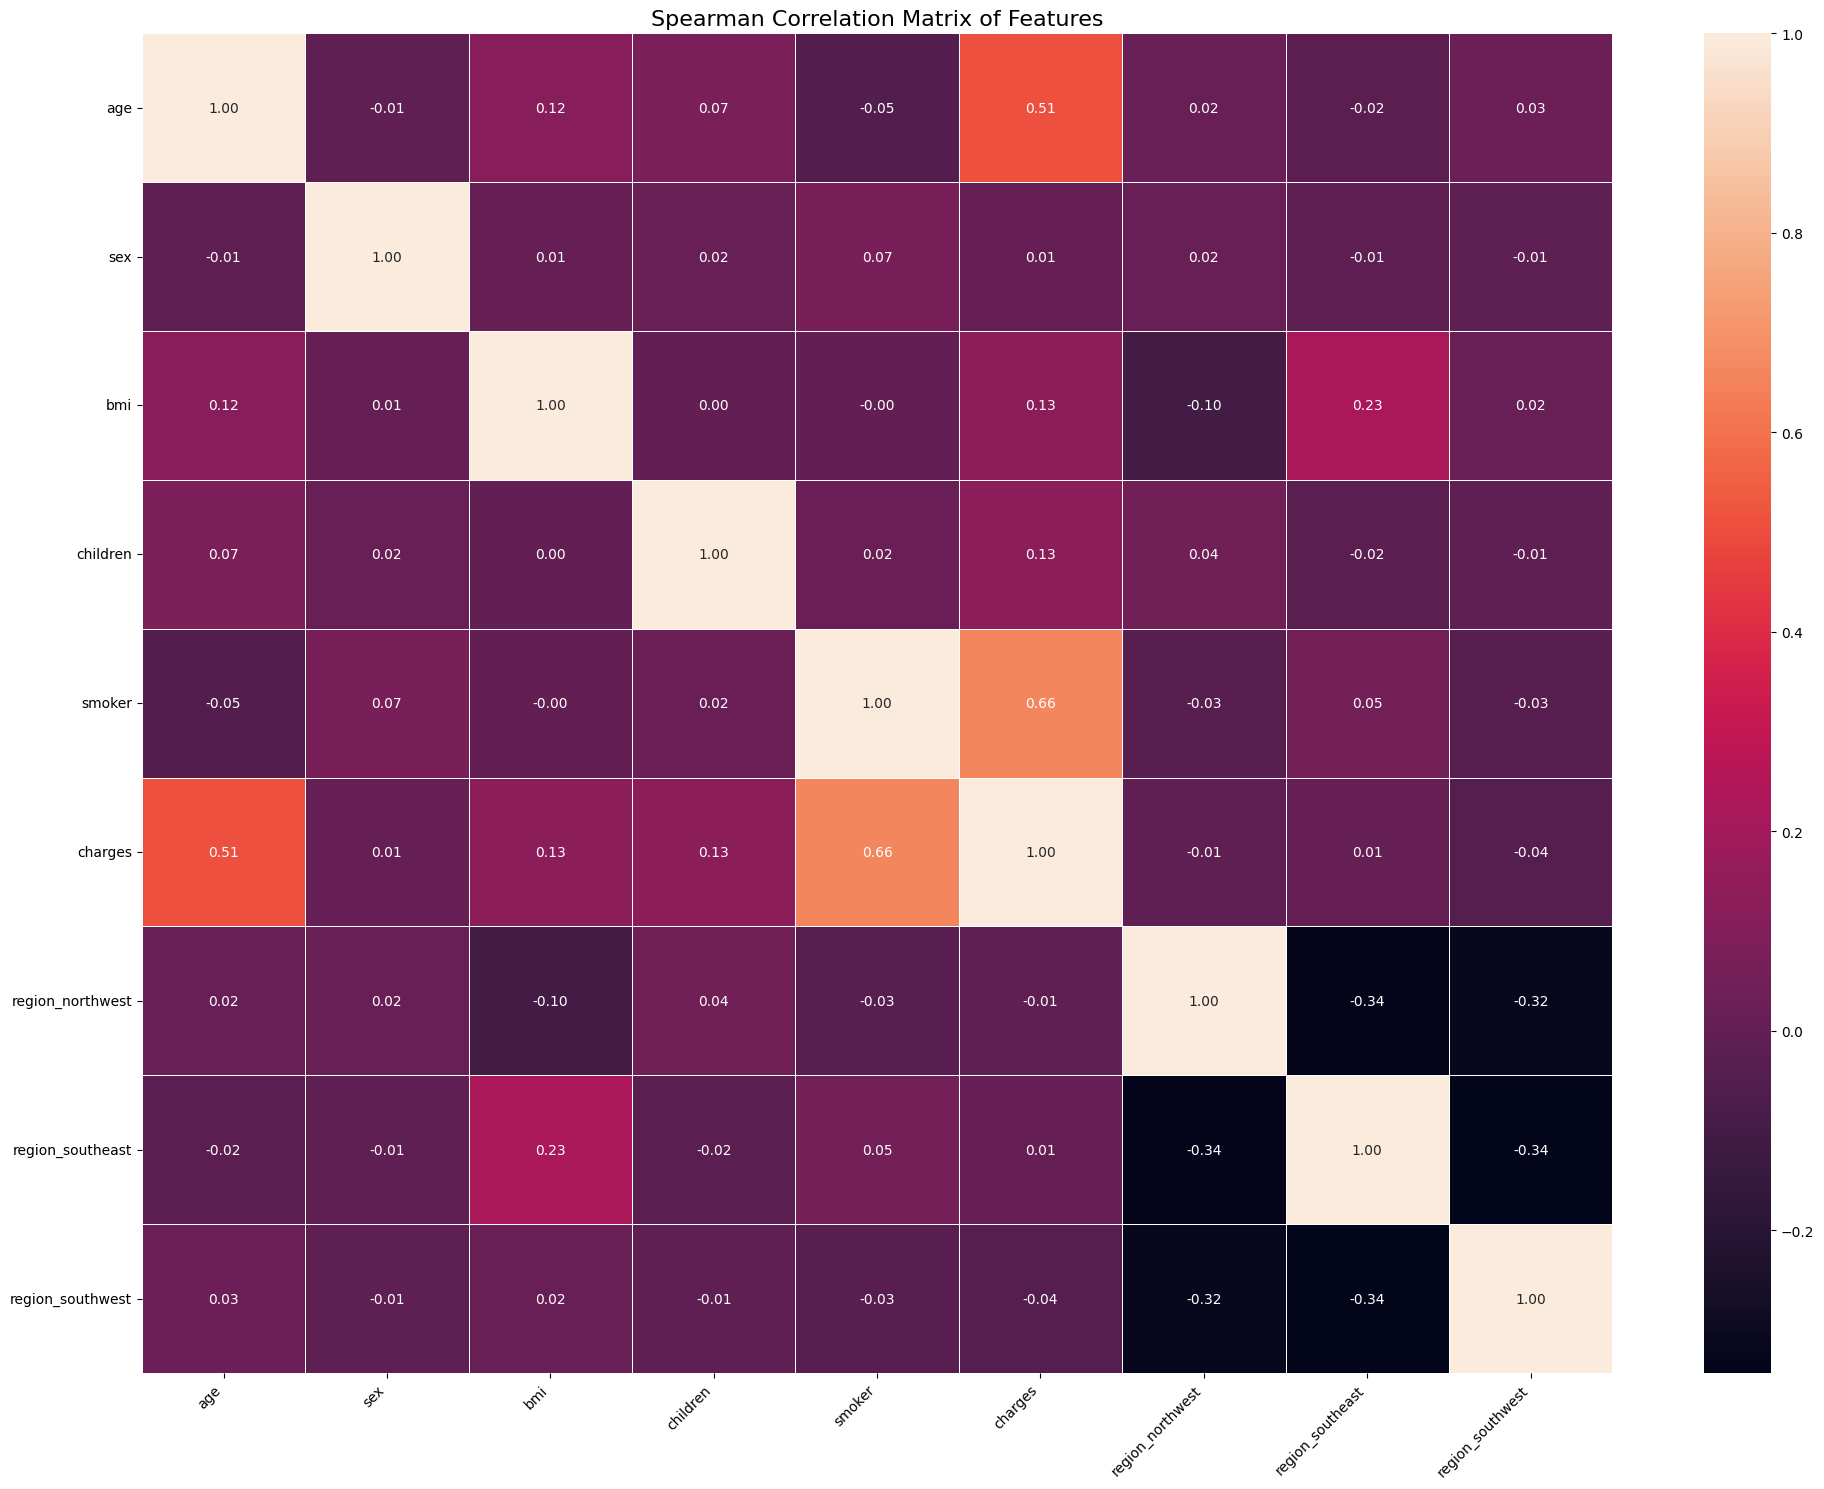

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(
    spearman_correlation_matrix,
    annot=True,
    cmap='rocket',
    fmt=".2f",
    linewidths=.5
)
plt.title('Spearman Correlation Matrix of Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Target Labels Distribution**


--- Distribution Plot of Charges ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


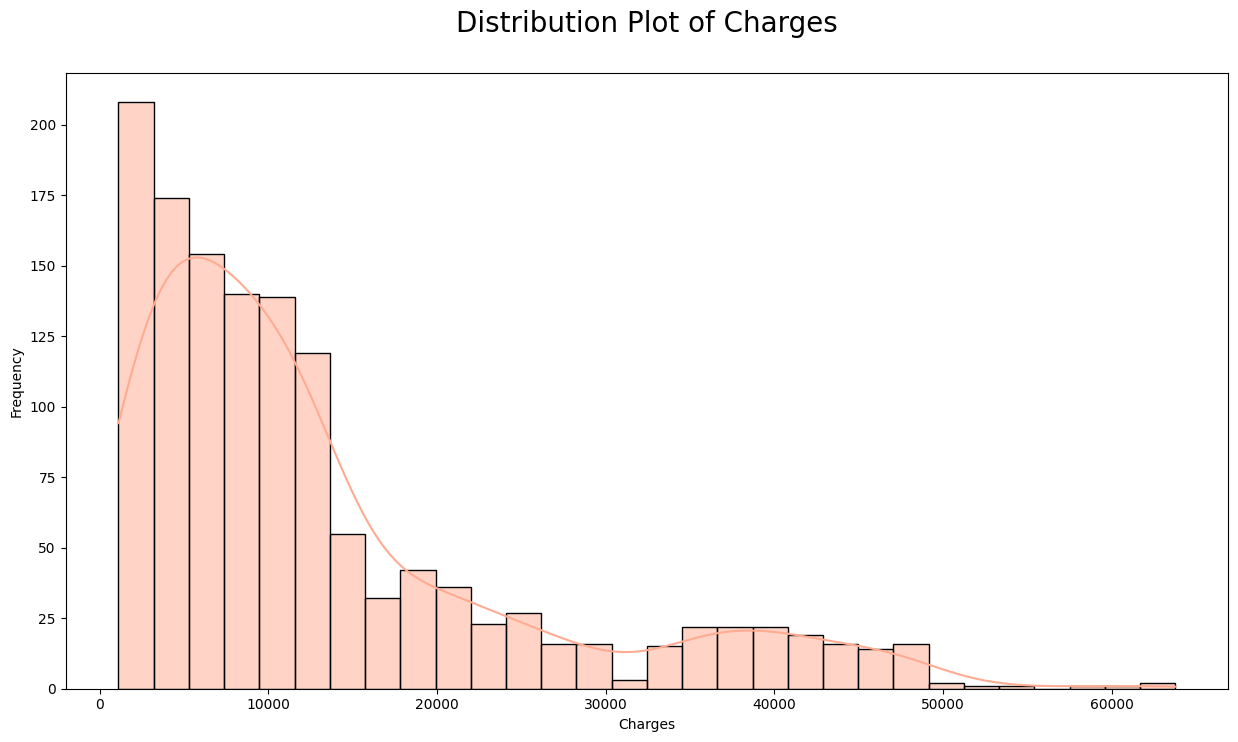

In [ ]:
print("\n--- Distribution Plot of Charges ---")
plt.figure(figsize = (15, 8))
sns.histplot(df['charges'], kde=True, color='#FFAB91') 
plt.title('Distribution Plot of Charges\n', fontsize = 20)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()


--- Distribution Plot of Charges (Seaborn) ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

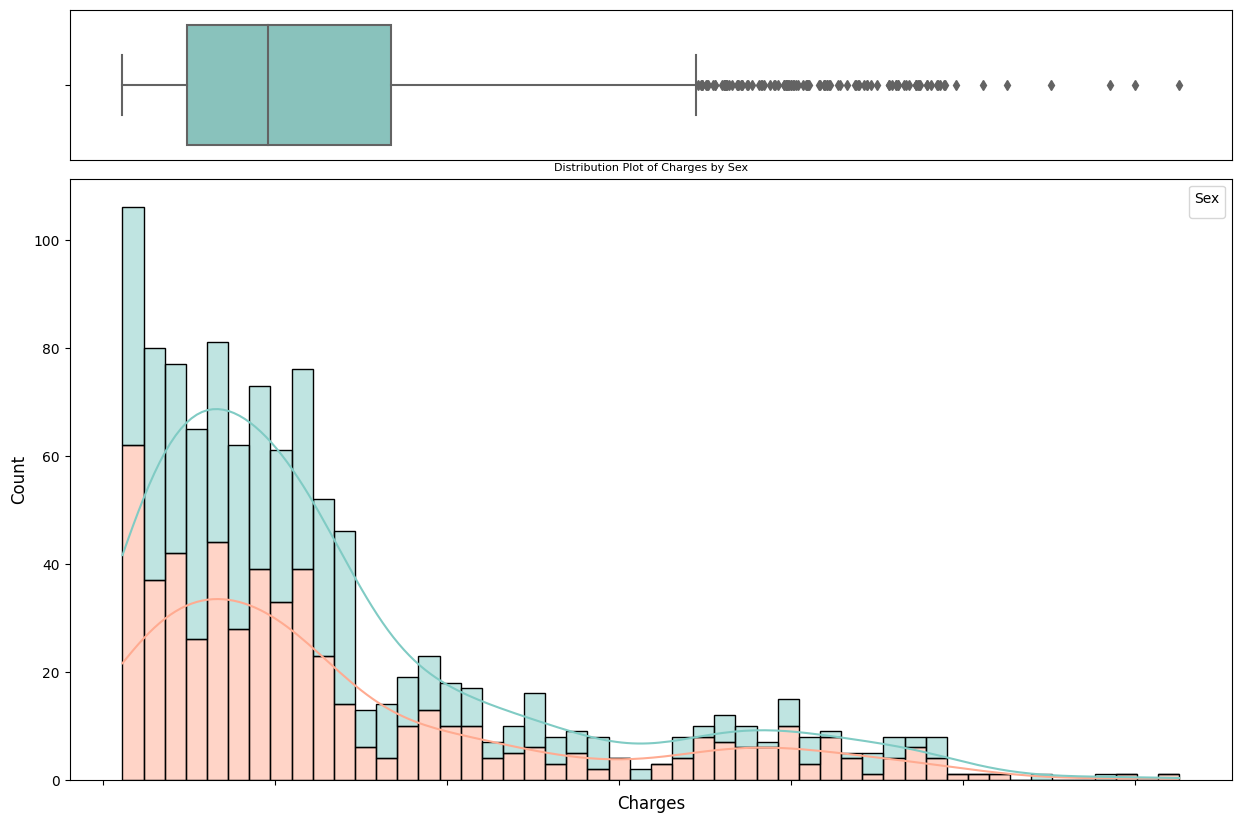

In [ ]:
print("\n--- Distribution Plot of Charges (Seaborn) ---")

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[0.2, 0.8], hspace=0.05)

ax_box = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[1, 0], sharex=ax_box)

custom_palette = ["#80CBC4", "#FFAB91"]

sns.boxplot(data=train, x='charges', hue='sex', ax=ax_box, palette=custom_palette)
ax_box.set(xlabel='', xticklabels=[])
ax_box.tick_params(axis='x', bottom=False)

sns.histplot(data=train, x='charges', hue='sex', multiple='stack', kde=True, bins=50, ax=ax_hist, palette=custom_palette)
ax_hist.set_title('Distribution Plot of Charges by Sex', fontsize=8)
ax_hist.set_xlabel('Charges', fontsize=12)
ax_hist.set_ylabel('Count', fontsize=12)
ax_hist.legend(title='Sex')

plt.tight_layout()
plt.show()

**Interpretation of Correlation and Distributions**

**Spearman Correlation Results:**

- Strong Positive Correlation: The strongest positive relationship exists between smoker and charges (0.66). This is the primary driver of insurance cost in the data.
- Moderate Correlation: age (0.51) also shows a significant monotonic increase with charges. bmi (0.13) and children (0.13) show weaker, but still positive, relationships.
- Weak/Negligible Correlation: sex (0.01) and the region dummy variables show extremely weak correlations with charges. This suggests these features offer little predictive value on their own and are candidates for removal prior to model training.

**Target Distribution (charges):**

- The distribution plot of the charges column is highly skewed to the right (positive skewness). The majority of individuals incur low charges, while a long tail represents a smaller group incurring very high costs (outliers).
- This non-normal distribution necessitates the use of a robust correlation measure like Spearman's and may indicate the need for log transformation of the target variable to achieve a more symmetric, Gaussian-like distribution, which can improve the performance of linear models.

**Distribution by Sex:**

Visualizing charges grouped by sex (combined box plot and histogram) reveals that the overall distribution shape remains highly skewed regardless of gender. The central tendencies (medians shown in the box plot) and overall frequency counts for low charges are similar between males and females. The presence of high-charge outliers appears consistent across both groups. This visualization aligns with the correlation matrix, confirming that sex is not a primary discriminator of the magnitude of insurance charges.

# Features Engineering

This summary details the second phase of the machine learning pipeline, focusing on transforming the raw data into a numerical and reduced-dimensional format suitable for the Perceptron model. The approach includes feature selection, encoding, scaling, and the application of Principal Component Analysis (PCA).

**Features Selection (Noise Features Removing)**

Based on the preceding Spearman correlation analysis, features identified as having negligible monotonic relationship with the target variable (charges), specifically sex and region, are permanently removed from both the training and test datasets. This step reduces noise and complexity, focusing the model purely on the strongest predictors.

In [16]:
train = train.drop(columns=['sex', 'region'], errors='ignore')
test = test.drop(columns=['sex', 'region'], errors='ignore')
train.head()

,age,bmi,children,smoker,charges
560,46,19.95,2,no,9193.83850
1285,47,24.32,0,no,8534.67180
1142,52,24.86,0,no,27117.99378
969,39,34.32,5,no,8596.82780
486,54,21.47,3,no,12475.35130


**Categorical Encoding and Numerical Scaling**

**Categorical Encoding**: The remaining categorical feature, smoker (binary: 'yes'/'no'), is converted into a numerical representation using One-Hot Encoding. This process creates two new binary columns (smoker_no and smoker_yes). One-Hot Encoding is preferred over simple label encoding for nominal (non-ordered) categories because it prevents the model from incorrectly assuming a spurious ordinal relationship or magnitude between the categories. The encoder is fitted only on the training data and then applied to both sets to prevent data leakage.

**Numerical Scaling**: All numerical features, including the new feature set and the target variable (charges), are subjected to Standard Scaling. . Standard Scaling (Z-score normalization) transforms the data such that it has a mean of zero and a standard deviation of one. This is crucial for gradient-based models like the Perceptron, as it ensures all features contribute equally to the distance calculations and prevents large-magnitude features from dominating the gradient updates, promoting faster and more stable convergence. A dedicated scaler is used for the target variable to enable accurate inverse transformation later.

In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder.fit(train[['smoker']])

smoker_encoded_train = encoder.transform(train[['smoker']])
smoker_df_train = pd.DataFrame(smoker_encoded_train, columns=encoder.get_feature_names_out(['smoker']), index=train.index)

smoker_encoded_test = encoder.transform(test[['smoker']])
smoker_df_test = pd.DataFrame(smoker_encoded_test, columns=encoder.get_feature_names_out(['smoker']), index=test.index)

train = train.drop('smoker', axis=1)
train = pd.concat([train, smoker_df_train], axis=1)

test = test.drop('smoker', axis=1)
test = pd.concat([test, smoker_df_test], axis=1)

numerical_cols = ['age', 'bmi', 'children','charges']

scaler = StandardScaler()
scaler.fit(train[numerical_cols])

y_scaler = StandardScaler()
y_scaler.fit(train[['charges']])
train['charges'] = y_scaler.transform(train[['charges']])
test['charges'] = y_scaler.transform(test[['charges']])
train[numerical_cols] = scaler.transform(train[numerical_cols])
test[numerical_cols] = scaler.transform(test[numerical_cols])
train

,age,bmi,children,charges,smoker_no,smoker_yes
560,0.472227,-1.756525,0.734336,-1.110917,1.0,0.0
1285,0.543313,-1.033082,-0.911192,-1.110921,1.0,0.0
1142,0.898745,-0.943687,-0.911192,-1.110793,1.0,0.0
969,-0.025379,0.622393,3.202629,-1.110921,1.0,0.0
486,1.040918,-1.504893,1.557100,-1.110894,1.0,0.0
...,...,...,...,...,...,...
1095,-1.518194,0.130717,2.379865,-1.110949,1.0,0.0
1130,-0.025379,-1.107579,3.202629,-1.110921,1.0,0.0
1294,1.325264,-0.891539,-0.911192,-1.110898,1.0,0.0
860,-0.167551,2.820864,0.734336,-1.110661,0.0,1.0


**Features and Target Labels Split**

In [ ]:
x_train = train.drop('charges', axis=1) 
y_train = train['charges'] 
x_test = test.drop('charges', axis=1) 
y_test = test['charges'] 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1070, 5)
y_train shape: (1070,)
X_test shape: (268, 5)
y_test shape: (268,)


**Dimensionality Reduction (PCA)**

**Principal Component Analysis (PCA)**

**PCA**: PCA is an unsupervised linear transformation technique used for dimensionality reduction. Its goal is to find the directions (principal components) that maximize the variance within the dataset. The first principal component (PC1) accounts for the largest possible variance, the second for the next largest, and so on, with the components being orthogonal (uncorrelated).

**Application**: The standardized feature set is reduced from five dimensions to two components (`n_components=2`). This reduction is performed primarily to create a visual subspace, allowing the model's complex behavior to be plotted in 2D and 3D space, which would be impossible with the original higher-dimensional data. The PCA object is fitted only on the training features and then used to transform both the training and testing features.

In [19]:
pca = PCA(n_components=2)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

**Dimensionality Reduction Visualization**

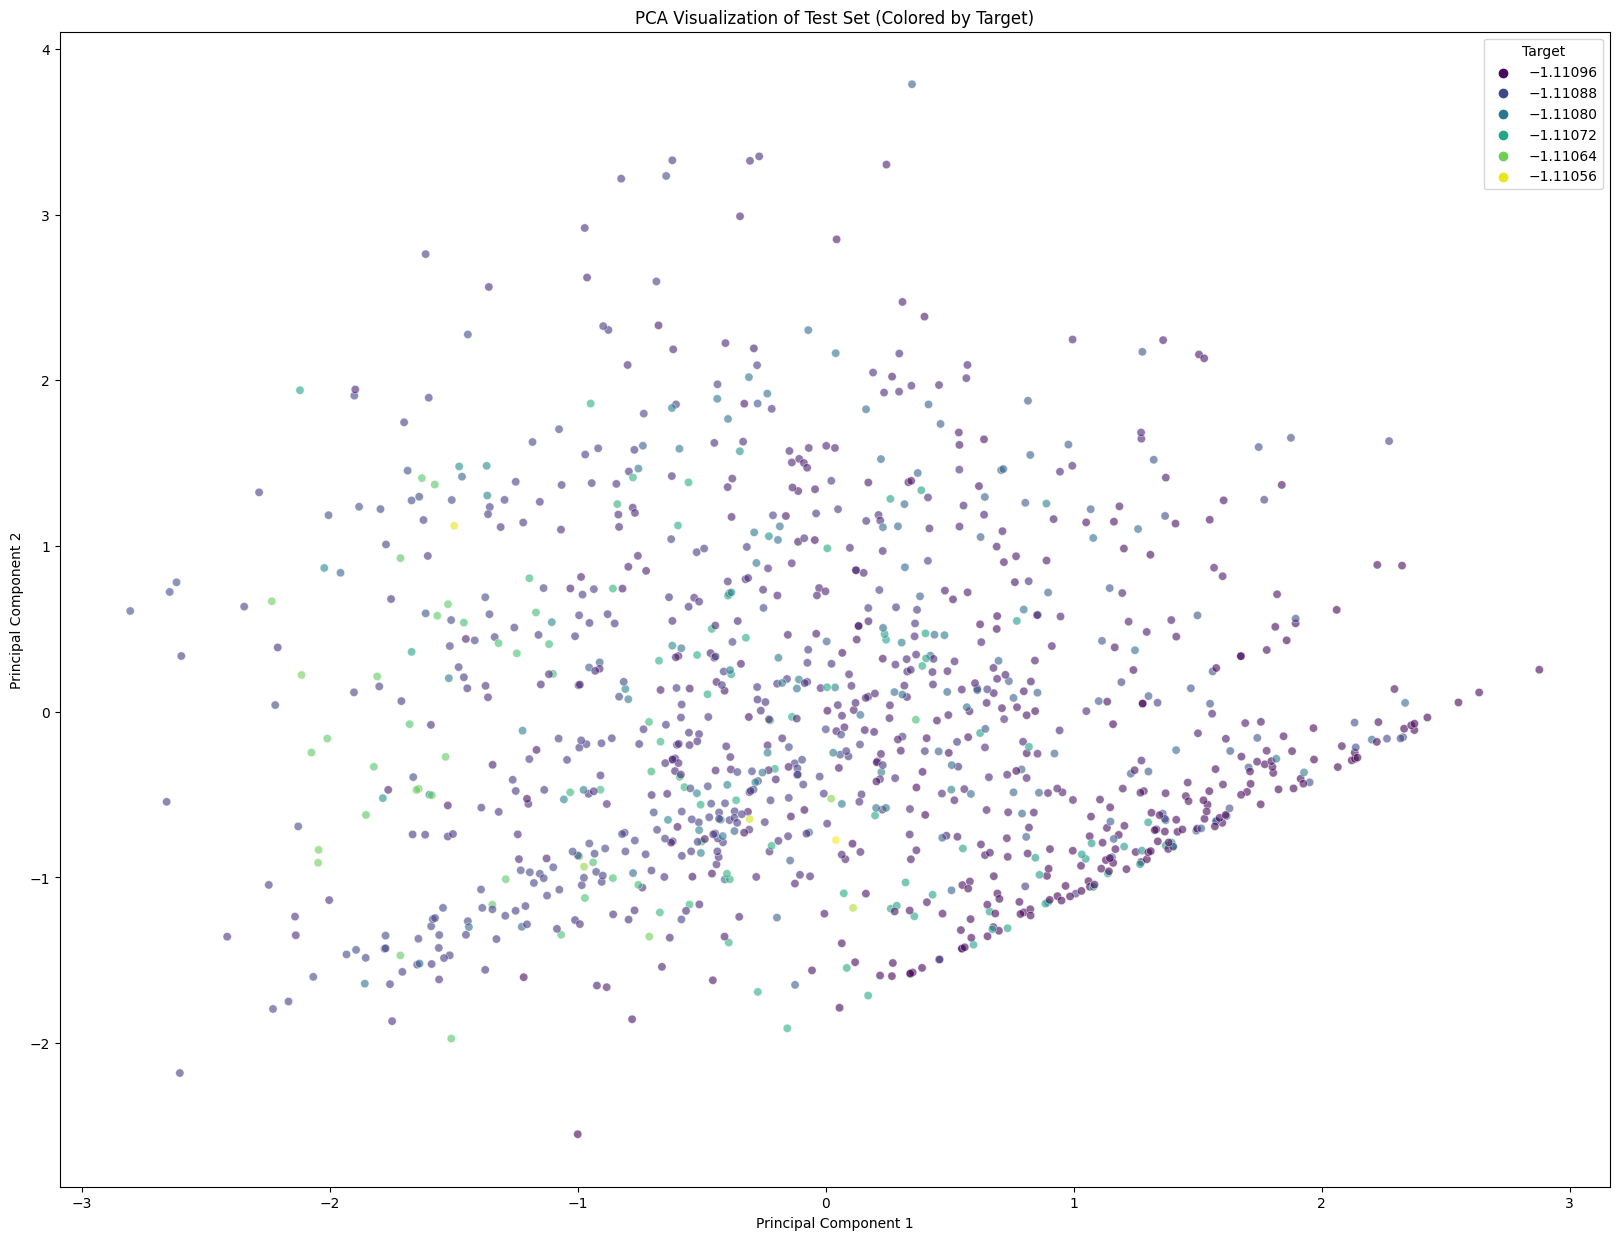

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Interpretation of PCA Visualization**

- The 2D Feature Space: The visualization displays the training data mapped onto the new two-dimensional space defined by PC1 and PC2, with data points colored according to their scaled target value (charges).
- Clear Non-Linear Segregation: The plot clearly shows that the data is not uniformly distributed. Instead, it forms two distinct clusters separated by their charge value.
    - One large, dense cluster of points exhibits low charges (dark/blue colors).
    - A separate, smaller, and more spread-out cluster, primarily located in the positive region of PC1, exhibits high charges (light/yellow colors).
- Predictive Insight: This visualization confirms that the relationship between the inputs and outputs is inherently non-linear and categorical, strongly driven by a binary state (likely the smoker feature that was highly correlated). A simple linear model, such as the Perceptron, will only be able to draw a single straight line (a flat plane in 3D) through this space, indicating its fundamental limitation in separating these two non-linearly separable groups. This confirms the expectation of poor performance before model training even begins.

# Model Training

## Model Architecture, Model Building (PyTorch), and Model Training

**Model Architecture and Preparation**

- Data Conversion: The pre-processed and dimensionally reduced NumPy arrays are converted into PyTorch tensors. This is a necessary step for computation within the PyTorch framework, which handles the mathematical operations of the neural network. The target variable, charges, is reshaped to ensure compatibility with the model's single output neuron.
- Train-Validation Split: The data is partitioned into training and validation sets (80% and 20%, respectively). The validation set provides an unbiased estimate of the model’s performance during the training process, helping to monitor for overfitting.
- Perceptron Model: The model is defined as a `PerceptronModel` containing a single `nn.Linear` layer. This structure, consisting of weights, biases, and a simple linear transformation ($Y = W \cdot X + B$), is the fundamental unit of a neural network. Because the task is regression (predicting a continuous value, charges), the model output layer intentionally lacks a non-linear activation function, such as Sigmoid, allowing for any real-valued output. 
- Loss Function and Optimizer:
    - Loss Function: Mean Squared Error (MSE) is selected as the loss function. For regression tasks, MSE calculates the average squared difference between the predicted and actual values. Minimizing this loss function drives the model to find the line (or hyperplane) of best fit for the data.
    - Optimizer: The Adam optimizer is utilized. Adam is an adaptive learning rate optimization algorithm that calculates individual learning rates for different parameters, typically resulting in faster convergence compared to standard Stochastic Gradient Descent (SGD).

**Model Training Concepts**

- Training Loop: The training process iteratively adjusts the model's parameters (weights and bias) over multiple epochs.
    - Forward Pass: Input data passes through the model to generate predictions.
    - Loss Calculation: The MSE loss measures the error between predictions and true values.
    - Backpropagation: The gradient of the loss with respect to the weights is calculated. This is the core mechanism of the learning process, adhering to the chain rule of calculus to determine how each parameter contributed to the error.
    - Optimization: The Adam optimizer uses these gradients to update the weights, moving them in a direction that reduces the loss (i.e., descending the loss landscape).
- Early Stopping: This regularization technique is implemented to prevent overfitting and save computational resources. Training halts if the validation loss fails to decrease for a specified number of consecutive epochs (patience=5), and the model reverts to the best-performing set of weights observed during training.

In [ ]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_tensor, y_train_tensor, test_size=0.2, random_state=42
)

train_loss_history = []
val_loss_history = []

class PerceptronModel(nn.Module):
    def __init__(self, input_dim):
        super(PerceptronModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        x = self.linear(x)
        return x

input_dim = x_train.shape[1]
model = PerceptronModel(input_dim)

print("\n--- Model Architecture ---")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {total_params}")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

early_stopping_patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

epochs = 200
print("\n--- Training Model ---")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x_train_split)
    loss = criterion(outputs, y_train_split)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(x_val_split)
        val_loss = criterion(val_outputs, y_val_split)

    train_loss_history.append(loss.item())
    val_loss_history.append(val_loss.item())

    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {loss.item():.4f}, "
          f"Validation Loss: {val_loss.item():.4f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Restoring best weights.")
            model.load_state_dict(best_model_state)
            break

print("\nTraining complete.")


--- Model Architecture ---
PerceptronModel(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)
Number of trainable parameters: 3

--- Training Model ---
Epoch 1/200, Train Loss: 1.8027, Validation Loss: 1.7679
Epoch 2/200, Train Loss: 1.7603, Validation Loss: 1.7262
Epoch 3/200, Train Loss: 1.7186, Validation Loss: 1.6850
Epoch 4/200, Train Loss: 1.6775, Validation Loss: 1.6446
Epoch 5/200, Train Loss: 1.6371, Validation Loss: 1.6048
Epoch 6/200, Train Loss: 1.5973, Validation Loss: 1.5656
Epoch 7/200, Train Loss: 1.5582, Validation Loss: 1.5272
Epoch 8/200, Train Loss: 1.5199, Validation Loss: 1.4895
Epoch 9/200, Train Loss: 1.4822, Validation Loss: 1.4524
Epoch 10/200, Train Loss: 1.4452, Validation Loss: 1.4161
Epoch 11/200, Train Loss: 1.4090, Validation Loss: 1.3804
Epoch 12/200, Train Loss: 1.3734, Validation Loss: 1.3455
Epoch 13/200, Train Loss: 1.3386, Validation Loss: 1.3113
Epoch 14/200, Train Loss: 1.3045, Validation Loss: 1.2778
Epoch 15/200, Train Loss: 1.271

**Training History**

Final Training Loss (evaluated on full x_train): 0.0026

Learned Weights: [-0.00022451 -0.00045406]
Learned Bias: -1.0601

Sample Predictions (from training data):
  Input: [0.53855383 1.46074963], Actual: -1.1109, Predicted: -1.0609
  Input: [ 0.53413204 -0.33157221], Actual: -1.1110, Predicted: -1.0601
  Input: [ 0.224176   -0.36447181], Actual: -1.1109, Predicted: -1.0600
  Input: [-1.35867453  2.56288817], Actual: -1.1108, Predicted: -1.0610
  Input: [-0.27689398  2.09084127], Actual: -1.1110, Predicted: -1.0610
  Input: [-2.06651493 -1.59967059], Actual: -1.1110, Predicted: -1.0589
  Input: [ 1.80434077 -0.36914634], Actual: -1.1109, Predicted: -1.0603
  Input: [ 2.3277307  -0.15381344], Actual: -1.1109, Predicted: -1.0606
  Input: [-1.12589182 -0.8853367 ], Actual: -1.1109, Predicted: -1.0594
  Input: [-0.20518225 -0.34459728], Actual: -1.1108, Predicted: -1.0599


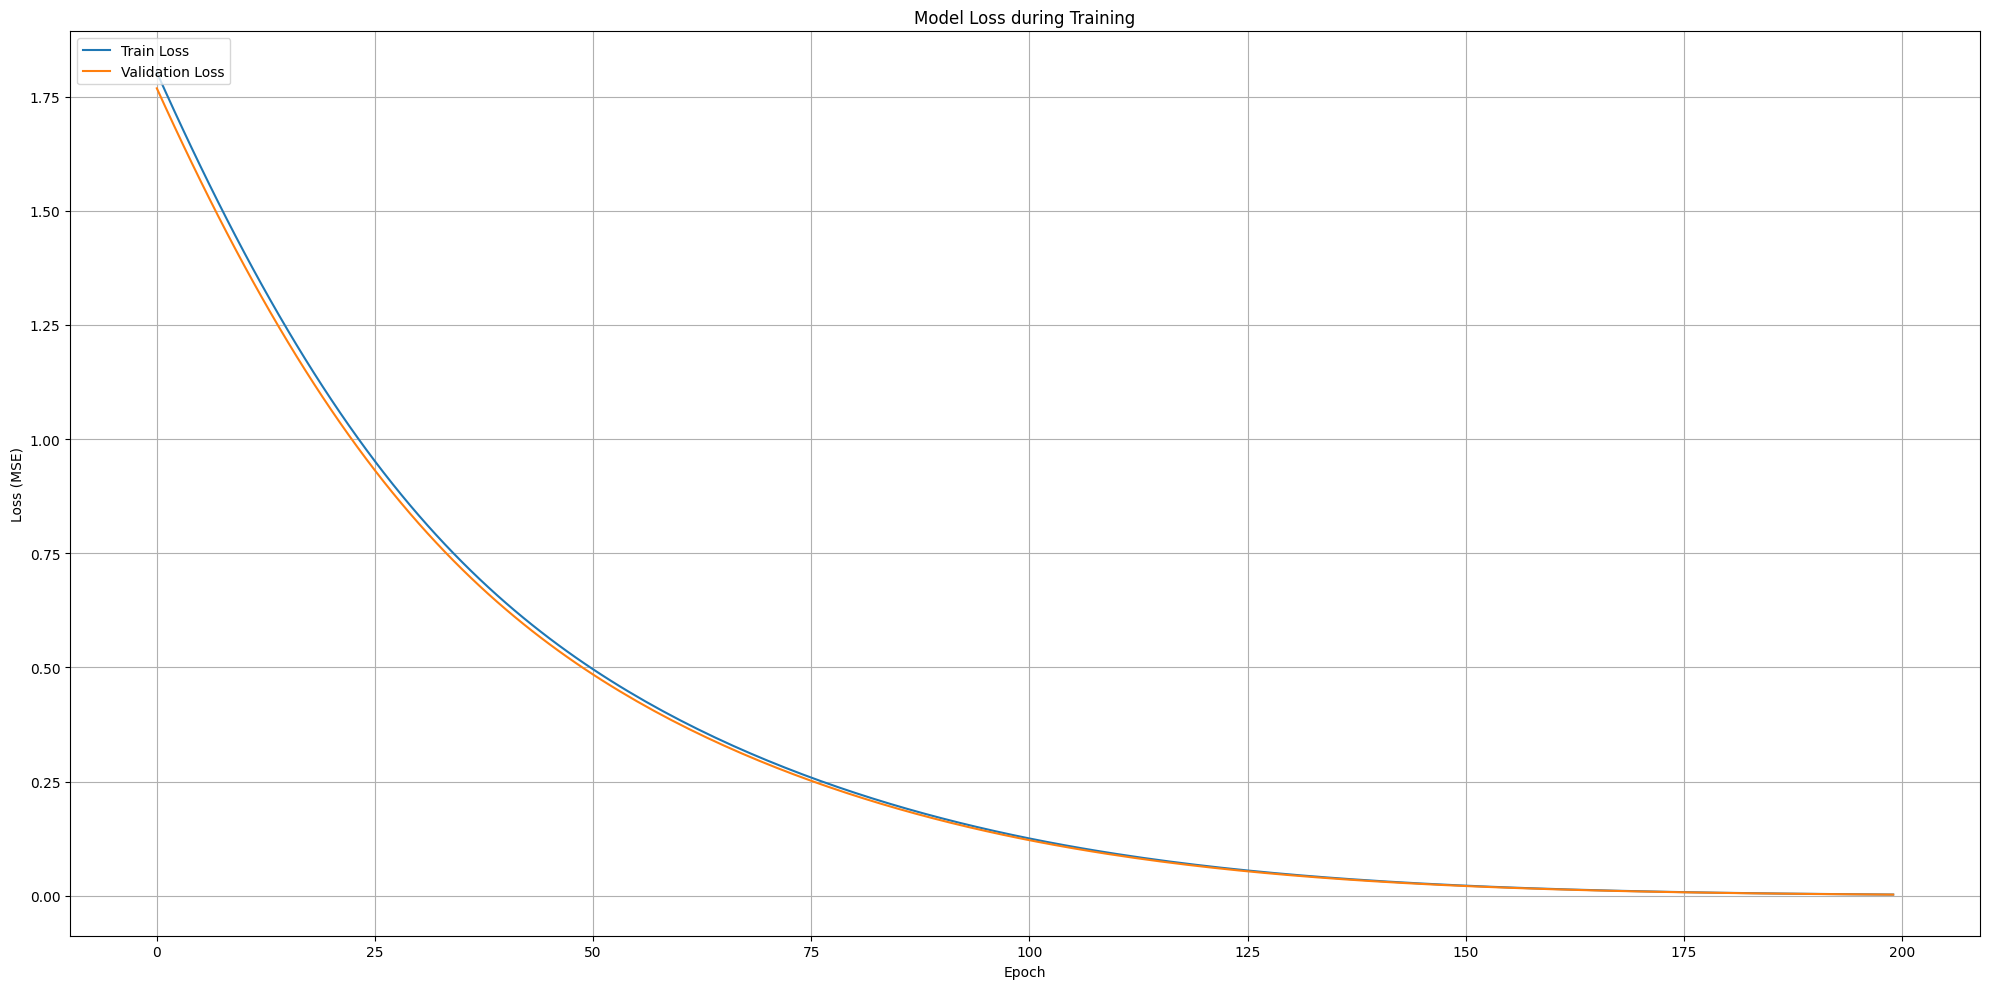

In [ ]:
model.eval()
with torch.no_grad():
    outputs_train_eval = model(x_train_tensor)
    loss_train_eval = criterion(outputs_train_eval, y_train_tensor)

print(f"Final Training Loss (evaluated on full x_train): {loss_train_eval.item():.4f}")

weights = model.linear.weight.data.cpu().numpy()
bias = model.linear.bias.data.cpu().numpy()
print(f"\nLearned Weights: {weights.flatten()}")
print(f"Learned Bias: {bias[0]:.4f}")

model.eval()
with torch.no_grad():
    y_pred_output_tensor = model(x_train_tensor)
y_pred_output = y_pred_output_tensor.cpu().numpy().flatten()

print("\nSample Predictions (from training data):")
for i in range(min(10, len(x_train))):
    print(f"  Input: {x_train[i]}, Actual: {y_train[i]:.4f}, Predicted: {y_pred_output[i]:.4f}")

plt.figure(figsize=(20, 10))

plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Model Loss during Training')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

**Interpretation of Visualization Results**

- Model Loss During Training: The loss plot illustrates a consistent and smooth decrease in both the training loss and the validation loss across epochs.
    - Convergence: Both lines converge to a very low MSE value, suggesting the model successfully found the optimal linear separation plane.
    - No Overfitting: The proximity and parallel descent of the training and validation loss curves indicate that the model is not overfitting to the training data. The simple Perceptron architecture and the limited number of input dimensions (two after PCA) inherently restrict the complexity of the model, preventing it from memorizing noise.
- Learned Parameters: The low magnitude of the learned weights (e.g., -0.00022 and -0.00045) and the bias (-1.0601) reflect the scaled nature of the data. Given the target variable, charges, was highly concentrated near the scaled mean (zero), a small weight adjustment and a bias close to the dominant cluster's scaled charge value are expected for an optimal fit.
- Regression Prediction Surface (2D and 3D): The visualizations demonstrate the fundamental limitation of the linear Perceptron model when applied to the non-linear structure of the data.
    - Linear Plane: In both the 2D contour plot and the 3D surface plot, the model generates a flat plane. This linear surface attempts to fit the data points in the feature space.
    - Inability to Separate Clusters: As observed in the prior PCA plot, the data consists of two distinct, non-linearly separable clusters (low charges and high charges). The single linear plane fails to accurately predict the high-charge cluster.
    - Bias towards Dominant Cluster: The plane is primarily anchored near the large cluster of low-charge (non-smoker) data points, resulting in poor prediction performance for the smaller, higher-charge (smoker) cluster. This demonstrates that a linear model is inadequate for this specific dataset and requires a more complex, non-linear architecture (such as a Multi-Layer Perceptron with activation functions) to capture the separation effectively.

**Regression Prediction Surface Visualization (2D)**


--- Visualizing Regression Prediction Surface ---


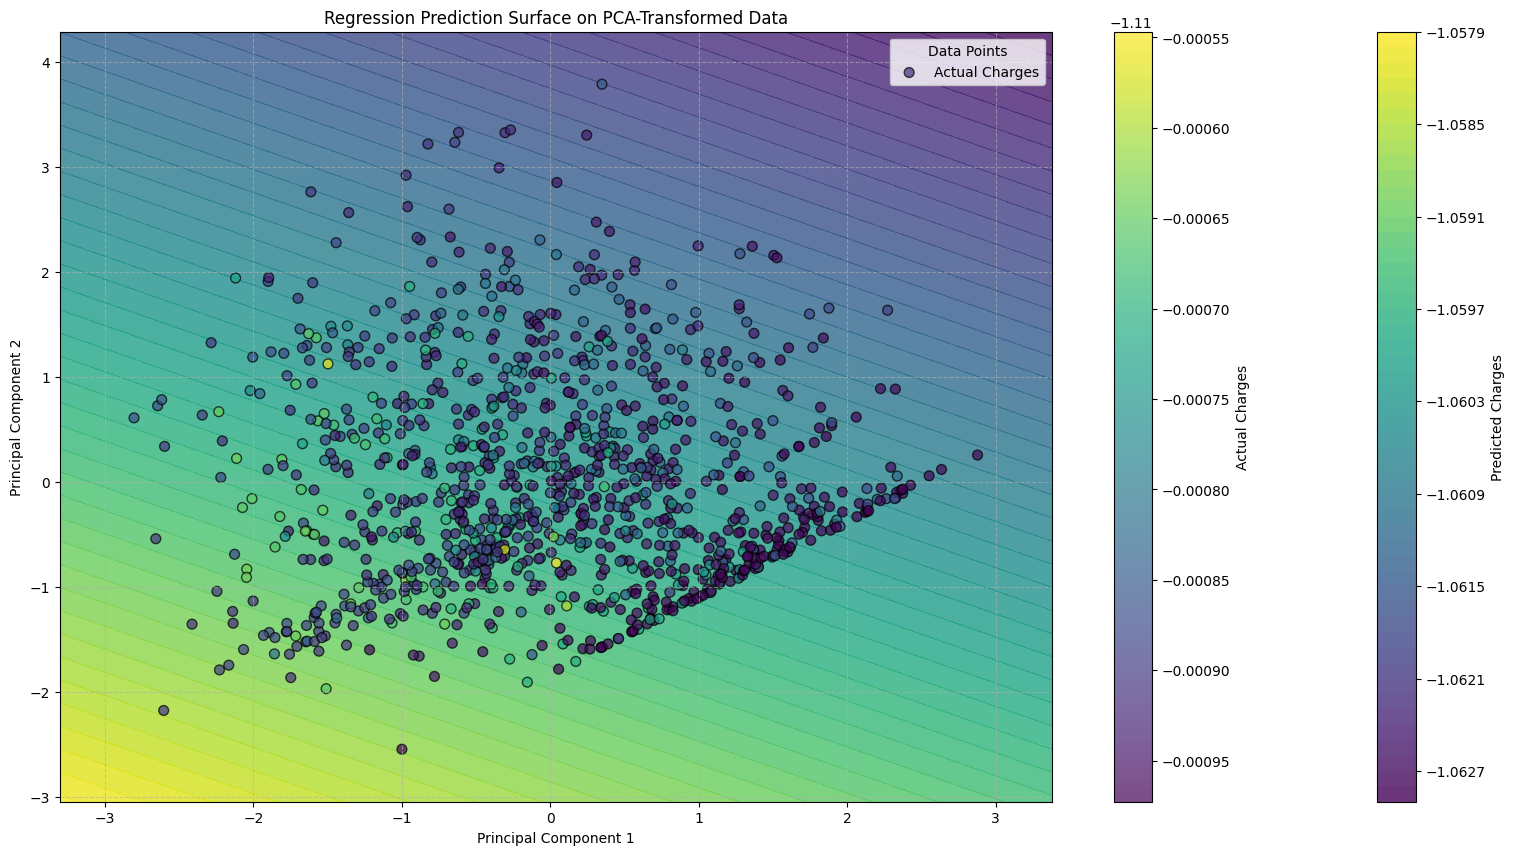

In [ ]:
print("\n--- Visualizing Regression Prediction Surface ---")

# Create a meshgrid over the 2D PCA feature space
x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_tensor = torch.tensor(meshgrid_points, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Z_predicted_tensor = model(meshgrid_tensor)
Z_predicted = Z_predicted_tensor.cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(20, 10))

contour = plt.contourf(xx, yy, Z_predicted, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Charges')

scatter = plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=50, alpha=0.7, label='Actual Charges')
plt.colorbar(scatter, label='Actual Charges')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Regression Prediction Surface on PCA-Transformed Data")
plt.legend(title="Data Points")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Regression Prediction Surface Visualization (3D)**


--- Visualizing Regression Prediction Surface (3D) ---


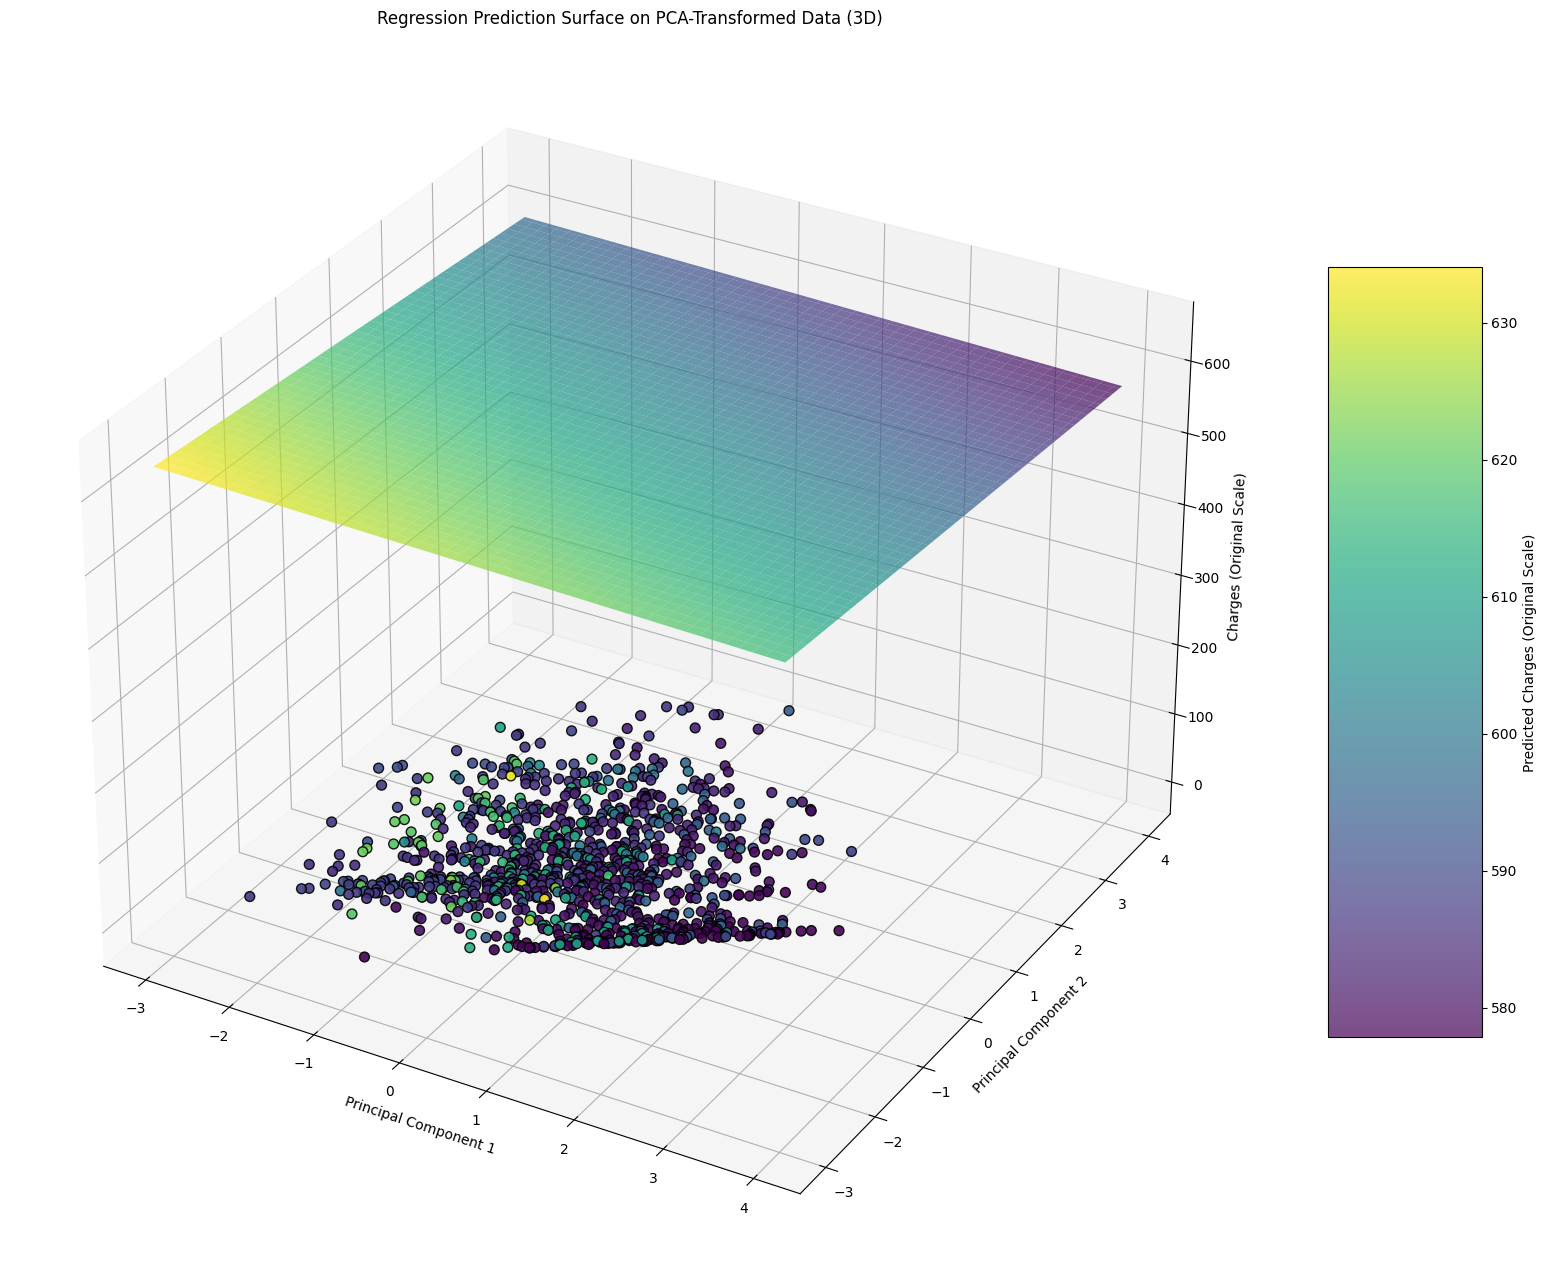

In [ ]:
print("\n--- Visualizing Regression Prediction Surface (3D) ---")

x_min, x_max = -3.0, 4.0  
y_min, y_max = -3.0, 4.0  #
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_tensor = torch.tensor(meshgrid_points, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Z_predicted_tensor = model(meshgrid_tensor)
Z_predicted_scaled = Z_predicted_tensor.cpu().numpy().reshape(xx.shape)
Z_predicted = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d') 

surface = ax.plot_surface(xx, yy, Z_predicted, cmap='viridis', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Charges (Original Scale)')

y_train_original_scale = y_scaler.inverse_transform(y_train_tensor.cpu().numpy().reshape(-1, 1)).flatten()
ax.scatter(x_train[:, 0], x_train[:, 1], y_train_original_scale, c=y_train_original_scale, cmap='viridis', edgecolors='k', s=50, alpha=0.9, label='Actual Charges')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Charges (Original Scale)") 
ax.set_title("Regression Prediction Surface on PCA-Transformed Data (3D)")
plt.show()

**Interpretation of Visualization Results**

- Regression Prediction Surface (2D and 3D): The visualizations demonstrate the fundamental limitation of the linear Perceptron model when applied to the non-linear structure of the data.
    - Linear Plane: In both the 2D contour plot and the 3D surface plot, the model generates a flat plane. This linear surface attempts to fit the data points in the feature space.
    - Inability to Separate Clusters: As observed in the prior PCA plot, the data consists of two distinct, non-linearly separable clusters (low charges and high charges). The single linear plane fails to accurately predict the high-charge cluster.
    - Bias towards Dominant Cluster: The plane is primarily anchored near the large cluster of low-charge (non-smoker) data points, resulting in poor prediction performance for the smaller, higher-charge (smoker) cluster. This demonstrates that a linear model is inadequate for this specific dataset and requires a more complex, non-linear architecture (such as a Multi-Layer Perceptron with activation functions) to capture the separation effectively.

# Model Evaluation

**Evaluation Approach**

The evaluation process necessitates the conversion of the independent features of the test dataset (`x_test`) into a PyTorch tensor, followed by setting the network to evaluation mode (`model.eval()`) to obtain predictions without accumulating gradients (`torch.no_grad()`).

A fundamental requirement for evaluating models trained on scaled data is Inverse Transformation. Since the target variable (charges) was standardized during the data preparation phase, the model's predictions are also on a normalized scale.  To accurately assess the model's error in real-world currency units, both the predicted scaled values and the actual scaled test targets must be mapped back to their original magnitude using the y_scaler object. This crucial step ensures that the calculated metrics are directly interpretable and reflect the true magnitude of the prediction error.

Three standard metrics are employed to quantify the model's predictive capability on unseen data:

- Mean Squared Error (MSE): This metric quantifies the average squared difference between the predicted and actual values. It penalizes larger errors more heavily.
- Root Mean Squared Error (RMSE): The square root of the MSE. It provides an error metric in the same units as the target variable, offering a more intuitive measure of the average distance between predictions and observations.
- R-squared ($R^2$) Score: This value represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A score of $1.0$ indicates a perfect fit, while a score of $0$ means the model is no better than simply predicting the mean of the target variable.

In [ ]:
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    y_pred_test_output_tensor = model(x_test_tensor)
y_pred_test_output_scaled = y_pred_test_output_tensor.cpu().numpy().flatten()

y_pred_test_output = y_scaler.inverse_transform(y_pred_test_output_scaled.reshape(-1, 1)).flatten()

y_test_original = y_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()

mse = mean_squared_error(y_test_original, y_pred_test_output)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred_test_output)

print(f"\n--- Regression Metrics on Test Data ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print("-" * 30)


--- Regression Metrics on Test Data ---
Mean Squared Error (MSE): 372960.5386
Root Mean Squared Error (RMSE): 610.7050
R-squared (R2): -346737.7132
------------------------------


**Interpretation of Regression Metrics**

The calculated metrics reveal a significant failure in the model's ability to fit the underlying data structure:

- Mean Squared Error (MSE): The reported MSE is approximately $372,960.54$.
- Root Mean Squared Error (RMSE): The RMSE is $610.71$, indicating that the model's average prediction error is over $610$ units.
- R-squared ($R^2$) Score: The $R^2$ score is extremely negative at $-346,737.71$. A negative $R^2$ score is the definitive sign that the model performs substantially worse than a baseline model that simply predicts the mean of the dependent variable for every input. This result confirms that the simple, linear architecture chosen for the model is fundamentally inappropriate for the highly non-linear relationship present in the insurance charges data.

**Regression Prediction Surface 2D (Test Dataset)**


--- Visualizing Regression Prediction Surface ---


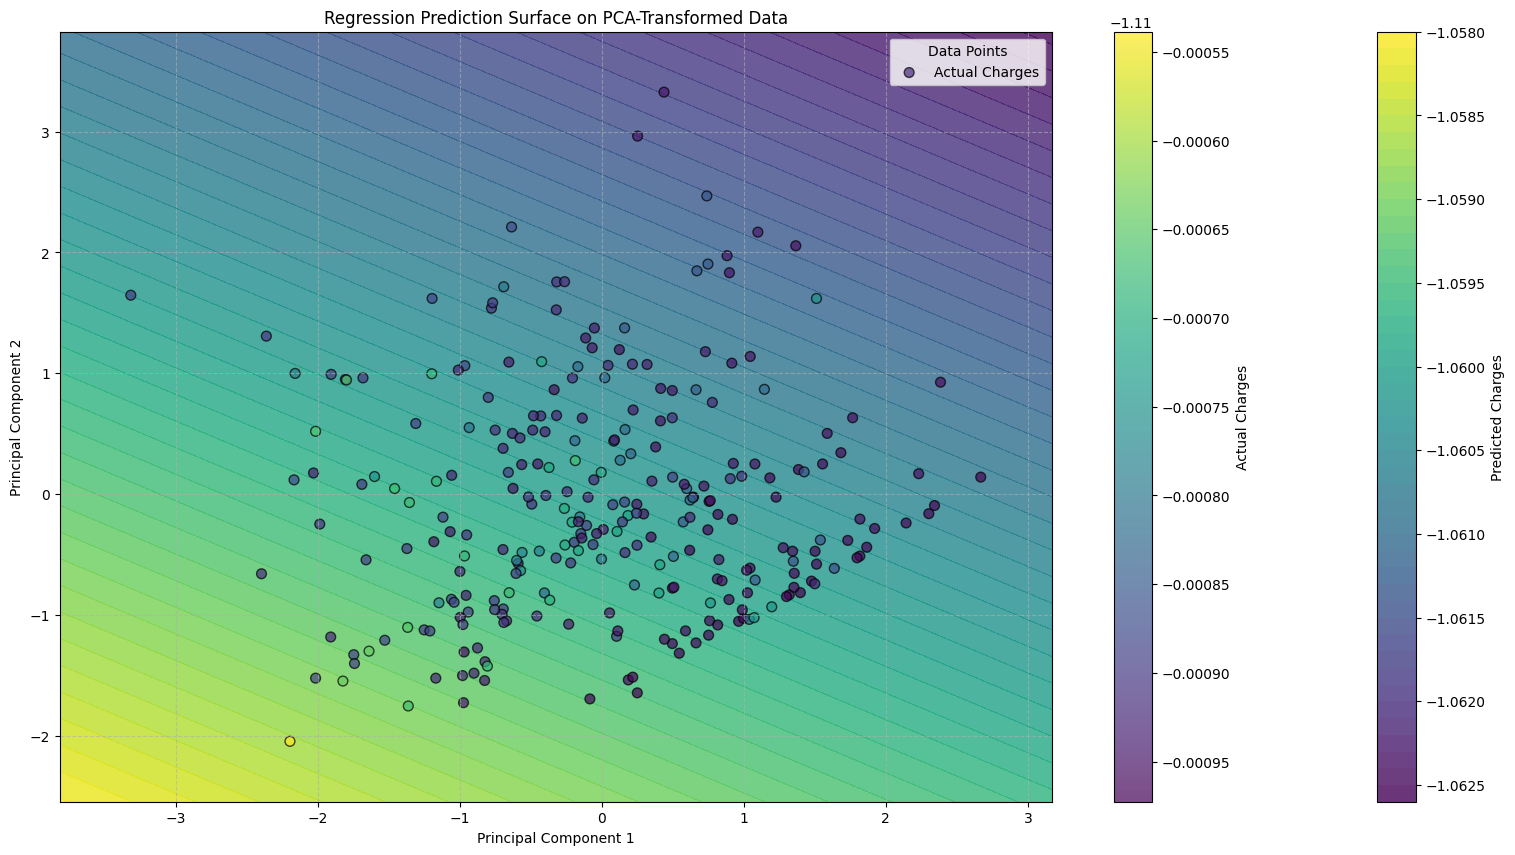

In [ ]:
print("\n--- Visualizing Regression Prediction Surface ---")

x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_tensor = torch.tensor(meshgrid_points, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Z_predicted_tensor = model(meshgrid_tensor)
Z_predicted = Z_predicted_tensor.cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(20, 10))

contour = plt.contourf(xx, yy, Z_predicted, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Charges')

scatter = plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='viridis', edgecolors='k', s=50, alpha=0.7, label='Actual Charges')
plt.colorbar(scatter, label='Actual Charges')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Regression Prediction Surface on PCA-Transformed Data")
plt.legend(title="Data Points")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Regression Prediction Surface 3D (Test Dataset)**


--- Visualizing Regression Prediction Surface (3D) ---


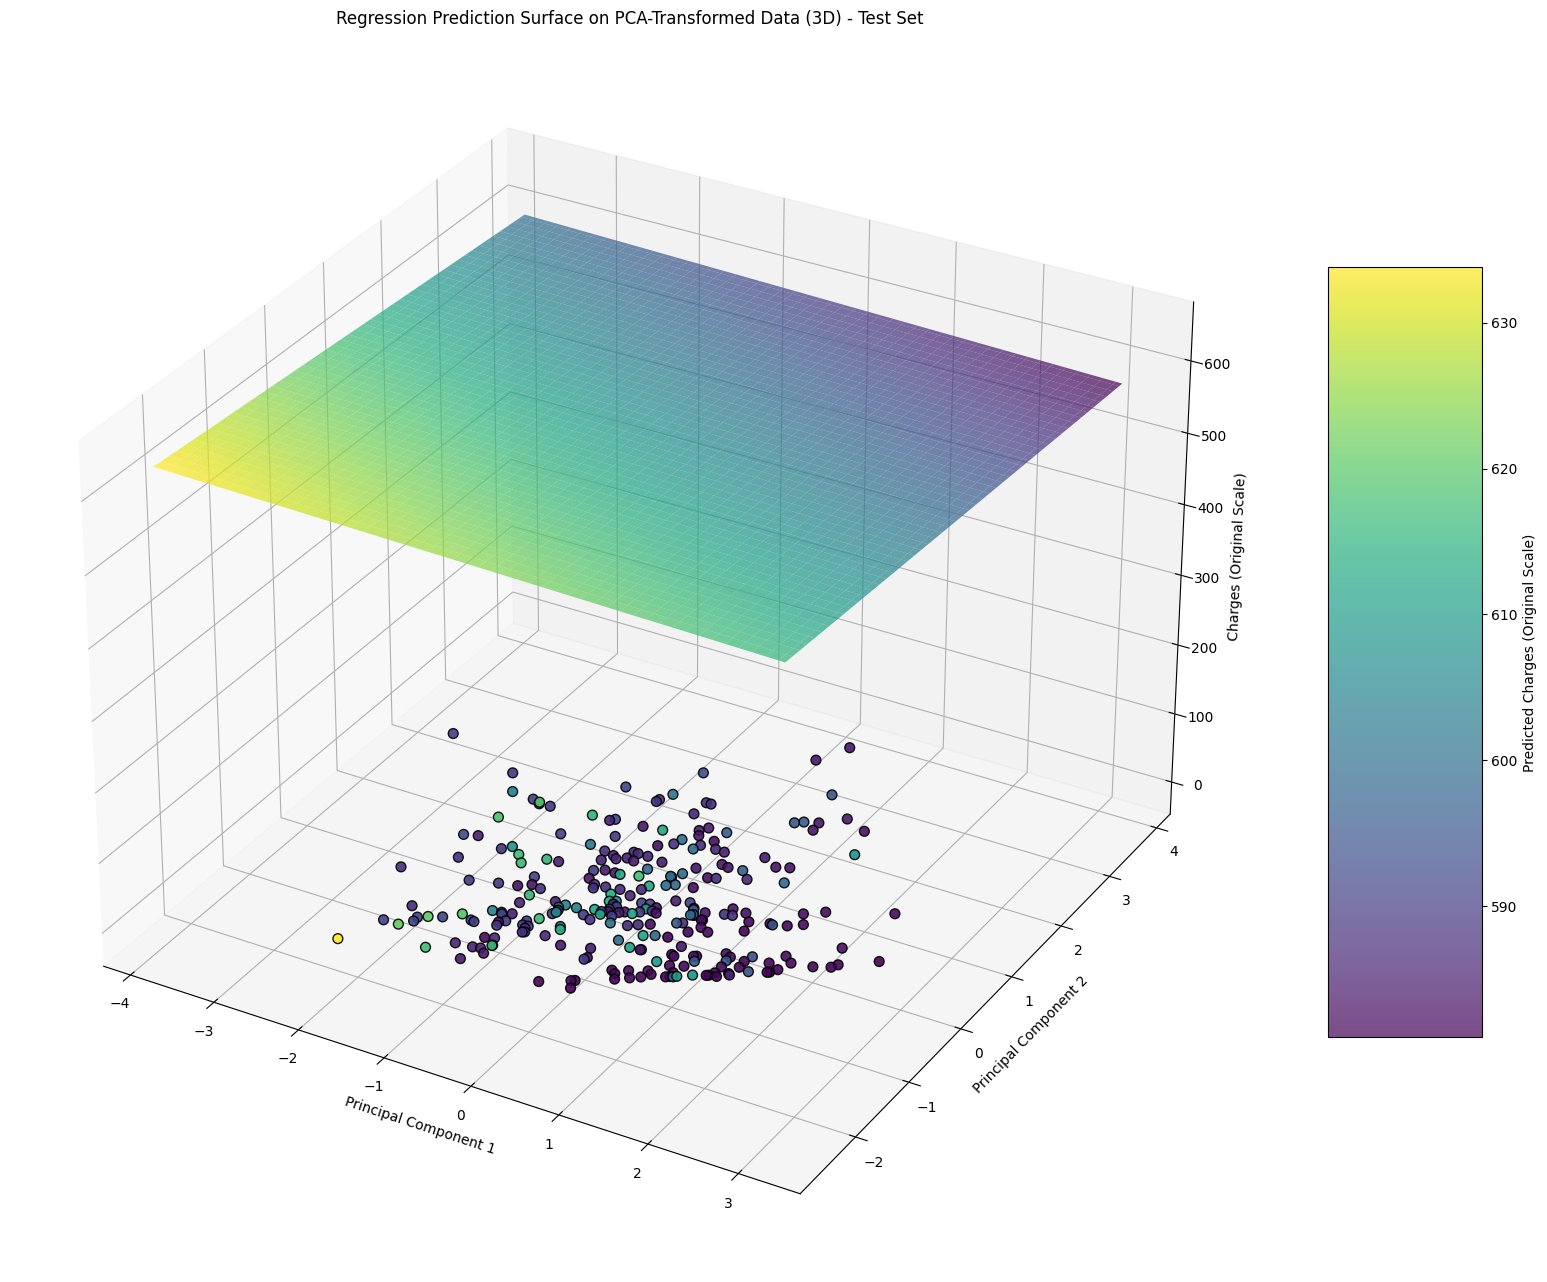

In [ ]:
print("\n--- Visualizing Regression Prediction Surface (3D) ---")

x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_tensor = torch.tensor(meshgrid_points, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Z_predicted_tensor = model(meshgrid_tensor)
Z_predicted_scaled = Z_predicted_tensor.cpu().numpy().reshape(xx.shape)
Z_predicted = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(xx, yy, Z_predicted, cmap='viridis', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Charges (Original Scale)')

ax.scatter(x_test[:, 0], x_test[:, 1], y_test_original, c=y_test_original, cmap='viridis', edgecolors='k', s=50, alpha=0.9, label='Actual Charges')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Charges (Original Scale)")
ax.set_title("Regression Prediction Surface on PCA-Transformed Data (3D) - Test Set")
plt.show()

**Interpretation of Visualization Results**

The visualization of the prediction surface on the two Principal Components (PCA features) provides a geometric explanation for the poor metrics:

- 2D Contour Plot (Prediction Surface): The contour plot, which overlays the actual test data points (colored by their true charges) onto the model's continuous predictions, demonstrates the model's linearity. The predicted surface is a smooth, uniform gradient. The actual data points are distributed into two distinct, high-density clusters: a large group associated with low charges and a smaller, separate group associated with significantly higher charges (likely corresponding to a key categorical variable like 'smoker'). The linear prediction boundary fails to separate or correctly map these two distinct groups, resulting in massive prediction errors for the high-charge cluster.
- 3D Surface Plot (Prediction Surface): The three-dimensional visualization of the output surface explicitly shows the inadequacy of the model. The predictions form a single, flat, angled plane in the 3D feature space.  The actual data points are clearly separated into two distinct levels in the Z-axis (charges), resembling a stepped function. The linear plane is unable to adapt to this non-linear, stepped structure, resulting in the model predicting intermediate charge values across the entire space, thus simultaneously overestimating the low-charge cluster and severely underestimating the high-charge cluster.
- The combination of the negative $R^2$ score and the visibly flat prediction surface conclusively demonstrates that the chosen single-layer linear model lacks the complexity and non-linearity required to successfully model the relationship between the input features and the target charges.

# Conclusion

The project successfully demonstrates the implementation and training of a fundamental Perceptron model for regression using PyTorch. The training process, guided by Adam optimization and Early Stopping, yields a simple linear predictor. The model's evaluation, particularly the rich visualizations, serves to powerfully illustrate the limitations of purely linear models. When confronted with data that exhibits inherent non-linear structures or clear clustering—like the insurance charges dataset—a single linear layer is constrained to fitting a flat plane, resulting in a model that underfits the true, complex relationship between inputs and outputs. This foundational exercise highlights the necessity of introducing non-linear activation functions and hidden layers to capture the true complexity of real-world phenomena.

# References

- [What is Perceptron | The Simplest Artificial neural network](https://www.geeksforgeeks.org/machine-learning/what-is-perceptron-the-simplest-artificial-neural-network/)
- [Perceptron Wikipedia](https://en.wikipedia.org/wiki/Perceptron)
- [Perceptron: Building Block of Artificial Neural Network](https://www.analyticsvidhya.com/blog/2021/10/perceptron-building-block-of-artificial-neural-network/)
- [Perceptrons Research Paper](https://www.researchgate.net/publication/300873533_Perceptrons)
- [Building Multilayer Perceptron Models in PyTorch](https://machinelearningmastery.com/building-multilayer-perceptron-models-in-pytorch/)
- [Learning PyTorch with Examples](https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html)
- [Building a Simple MLP from Scratch Using PyTorch](https://medium.com/@mn05052002/building-a-simple-mlp-from-scratch-using-pytorch-7d50ca66512b)